In [1]:
import pandas as pd
import numpy as np
import keras
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
dataset_df = pd.read_csv('../dataset/open-meteo_newDataset.csv')

In [3]:
dataset_df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²)
0,2019-01-01T00:00,16.7,82,13.6,15.4,0.1,97,53,20,0,0.06,0.34,48.2,0.0,48.2,0.0,368.1
1,2019-01-01T01:00,17.2,85,14.6,16.0,0.1,100,100,42,0,0.08,0.30,128.6,16.1,112.5,46.1,609.9
2,2019-01-01T02:00,17.1,80,13.6,15.8,0.1,100,100,47,0,0.09,0.39,104.4,4.5,99.9,9.0,794.1
3,2019-01-01T03:00,18.0,77,14.0,16.6,0.0,100,100,43,0,0.14,0.47,187.5,7.4,180.1,12.2,908.4
4,2019-01-01T04:00,17.9,78,14.0,16.6,0.1,100,100,42,0,0.14,0.45,194.4,13.2,181.2,19.9,944.8


In [4]:
dataset_df.columns

Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'dew_point_2m (°C)', 'apparent_temperature (°C)', 'rain (mm)',
       'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)',
       'cloud_cover_high (%)', 'et0_fao_evapotranspiration (mm)',
       'vapour_pressure_deficit (kPa)', 'shortwave_radiation_instant (W/m²)',
       'direct_radiation_instant (W/m²)', 'diffuse_radiation_instant (W/m²)',
       'direct_normal_irradiance_instant (W/m²)',
       'terrestrial_radiation_instant (W/m²)'],
      dtype='object')

In [5]:
dataset_df['time'] = pd.to_datetime(dataset_df['time'])
dataset_df['month'] = dataset_df['time'].dt.month

# Pisahkan data berdasarkan bulan
january_df = dataset_df[dataset_df['month'] == 1]
february_df = dataset_df[dataset_df['month'] == 2]
march_df = dataset_df[dataset_df['month'] == 3]
april_df = dataset_df[dataset_df['month'] == 4]
may_df = dataset_df[dataset_df['month'] == 5]
june_df = dataset_df[dataset_df['month'] == 6]
july_df = dataset_df[dataset_df['month'] == 7]
august_df = dataset_df[dataset_df['month'] == 8]
september_df = dataset_df[dataset_df['month'] == 9]
october_df = dataset_df[dataset_df['month'] == 10]
november_df = dataset_df[dataset_df['month'] == 11]
december_df = dataset_df[dataset_df['month'] == 12]

In [6]:
january_df.set_index('time', inplace=True)
february_df.set_index('time', inplace=True)
march_df.set_index('time', inplace=True)
april_df.set_index('time', inplace=True)
may_df.set_index('time', inplace=True)
june_df.set_index('time', inplace=True)
july_df.set_index('time', inplace=True)
august_df.set_index('time', inplace=True)
september_df.set_index('time', inplace=True)
october_df.set_index('time', inplace=True)
november_df.set_index('time', inplace=True)
december_df.set_index('time', inplace=True)

# January

In [7]:
data_features = january_df[['shortwave_radiation_instant (W/m²)', 'direct_radiation_instant (W/m²)',
       'direct_normal_irradiance_instant (W/m²)', 'diffuse_radiation_instant (W/m²)', 'et0_fao_evapotranspiration (mm)', 'cloud_cover (%)',
       'terrestrial_radiation_instant (W/m²)']].values
data_target = january_df['shortwave_radiation_instant (W/m²)'].values

In [8]:
print(len(data_features))

744


In [9]:
look_back = 504 #menggunakan timestamp 24
n_ahead = 12 # predict 24 jam berikutnya

x_seq = []
y_seq = []

for i in range(len(data_features) - look_back - n_ahead + 1):
    x_seq.append(data_features[i : (i + look_back)]) # mengambil value 24 jam sebelum
    y_seq.append(data_target[(i + look_back) : (i + look_back + n_ahead)]) #mengambil value 24 jam berikutnya

x_seq, y_seq = np.array(x_seq), np.array(y_seq)

In [10]:
print(x_seq.shape)
print(y_seq.shape)

(229, 504, 7)
(229, 12)


In [11]:
split_point = int(len(x_seq) * 0.8) # 80% for training and 20% for testing

x_train, x_test = x_seq[:split_point], x_seq[split_point:]
y_train, y_test = y_seq[:split_point], y_seq[split_point:]

#flatten the y

y_train = y_train.flatten()
y_test = y_test.flatten()

print(f'x_train shape: {x_train.shape}, x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')

x_train shape: (183, 504, 7), x_test shape: (46, 504, 7)
y_train shape: (2196,), y_test shape: (552,)


In [12]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_x = RobustScaler()
scaler_y = RobustScaler()

#fit dan transform the training data
#kalau mau fit transform, data harus 2 dimensi. untuk x, kembalikan ke 3 dimensi. untuk y, kembalikan 1 dimensi
x_train_scaled = scaler_x.fit_transform(x_train.reshape(-1, x_train.shape[2])).reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2]) 
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, n_ahead))
# y_train_scaled = y_train_scaled.flatten()

# tranform the testing data
x_test_scaled = scaler_x.fit_transform(x_test.reshape(-1, x_train.shape[2])).reshape(x_test.shape[0], x_test.shape[1], x_train.shape[2])
y_test_scaled = scaler_y.transform(y_test.reshape(-1, n_ahead))
# y_test_scaled = y_test_scaled.flatten()

# # Reshape X_train and X_test to 3D for LSTM input (samples, time steps, features)
# X_train_scaled = X_train.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
# X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Check the shapes after standardization
print(f'X_train_scaled shape: {x_train_scaled.shape}, X_test_scaled shape: {x_test_scaled.shape}')
print(f'y_train_scaled shape: {y_train_scaled.shape}, y_test_scaled shape: {y_test_scaled.shape}')

X_train_scaled shape: (183, 504, 7), X_test_scaled shape: (46, 504, 7)
y_train_scaled shape: (183, 12), y_test_scaled shape: (46, 12)


# Build Model

In [13]:
import tensorflow as tf

In [14]:
def build_model(n_input, n_output, num_features):
    tf.keras.backend.clear_session() 
    
    # Encoder Input
    encoder_inputs = tf.keras.Input(shape=(n_input, num_features))
    encoder_lstm = encoder_inputs     

    # Encoder LSTM
    encoder_lstm = tf.keras.layers.LayerNormalization(epsilon=1e-6)(encoder_lstm) 
    encoder_lstm = tf.keras.layers.LSTM(units=32, name="lstm_encoder_hidden", return_sequences=True, 
                        kernel_initializer='he_normal',
                        kernel_regularizer=tf.keras.regularizers.l2(0.01))(encoder_lstm)
    encoder_lstm = tf.keras.layers.Dropout(0.25)(encoder_lstm)
    encoder_lstm, state_h, state_c = tf.keras.layers.LSTM(units=32, return_state=True, return_sequences=True, 
                                          name="lstm_encoder")(encoder_lstm)

    # Decoder LSTM with initial state from encoder LSTM   
    decoder_lstm = tf.keras.layers.LSTM(units=32, return_sequences=True, name="lstm_decoder")(encoder_lstm, initial_state=[state_h, state_c])    
    decoder_lstm = tf.keras.layers.LayerNormalization(epsilon=1e-6)(decoder_lstm)
    # decoder_lstm = LSTM(units=168, name="lstm_decoder_hidden", return_sequences=True)(decoder_lstm)
    decoder_lstm = tf.keras.layers.Dropout(0.2)(decoder_lstm)
    decoder_lstm = tf.keras.layers.LSTM(units=32, name="lstm_decoder_final", return_sequences=False)(decoder_lstm)    
    
    for dim in [24]:
        decoder_lstm = tf.keras.layers.Dense(dim, activation="relu")(decoder_lstm)
        decoder_lstm = tf.keras.layers.Dropout(0.2)(decoder_lstm)   

    outputs = tf.keras.layers.Dense(n_output)(decoder_lstm)

    # Model
    model = tf.keras.Model(encoder_inputs, outputs)    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipvalue=0.01), loss='mse')

    return model

In [15]:
model = build_model(n_input=look_back, n_output=n_ahead, num_features=x_train_scaled.shape[2])     

In [16]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)    

history = model.fit(x_train_scaled, y_train_scaled, 
                        # shuffle=False,
                        epochs=100, 
                        batch_size=None, 
                        validation_split=0.2,
                        callbacks=[early_stopping]
                        )

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 277ms/step - loss: 3.7079 - val_loss: 3.5614
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - loss: 3.4899 - val_loss: 3.4685
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - loss: 3.3685 - val_loss: 3.3931
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - loss: 3.3069 - val_loss: 3.3298
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - loss: 3.2715 - val_loss: 3.2705
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - loss: 3.1779 - val_loss: 3.2136
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - loss: 3.2024 - val_loss: 3.1504
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - loss: 3.0901 - val_loss: 3.0657
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - loss: 3.0189 - val_loss: 2.9844
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - loss: 2.8854 - val_loss: 2.8851
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - loss: 2.8177 - val_loss: 2.7967
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - loss: 2.7

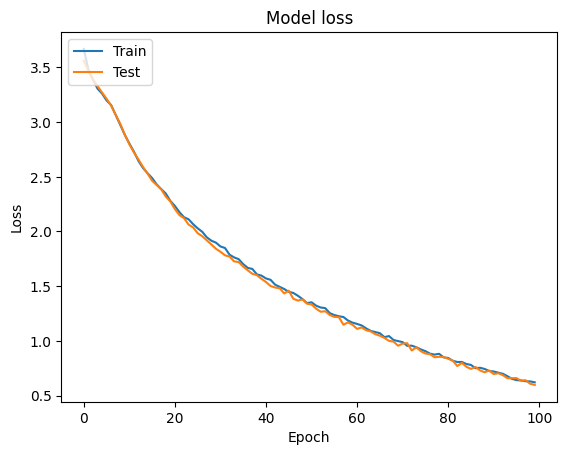

In [17]:
# prompt: plot the loss history of training and validation

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [18]:
#Evaluate the model

test_loss = model.evaluate(x_test_scaled, y_test_scaled)
print(f"Test Loss: {test_loss}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.8847
Test Loss: 0.8723257184028625


In [19]:
# Make predictions on the test set
y_pred_scaled = model.predict(x_test_scaled)

# De-standardize the predictions using the same scaler as for y
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# De-standardize the actual values
y_test = scaler_y.inverse_transform(y_test_scaled).flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 339ms/step


In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')

Mean Absolute Error (MAE): 88.55945179163871
Mean Squared Error (MSE): 20109.33317843543


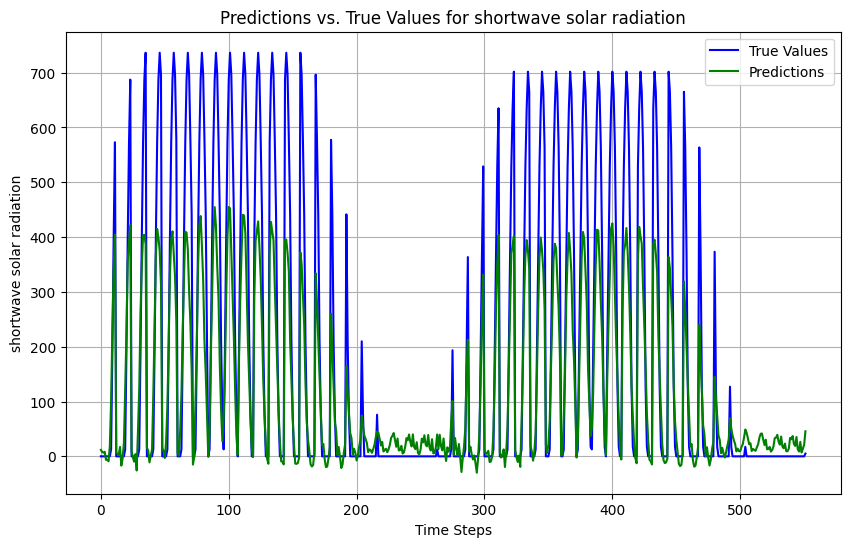

In [21]:
# prompt: plot the prediction vs true test

# Plot the predictions vs. true values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='True Values', color='blue')
plt.plot(y_pred, label='Predictions', color='green')
plt.title('Predictions vs. True Values for shortwave solar radiation')
plt.xlabel('Time Steps')
plt.ylabel('shortwave solar radiation')
plt.legend()
plt.grid(True)
plt.show()

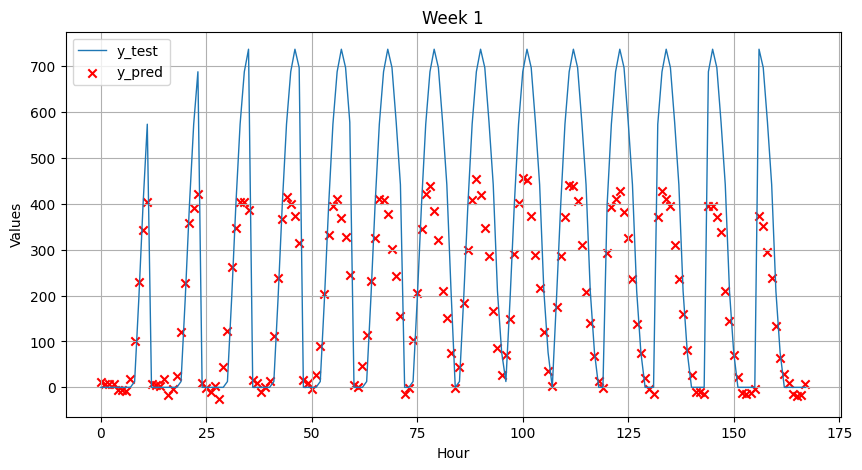

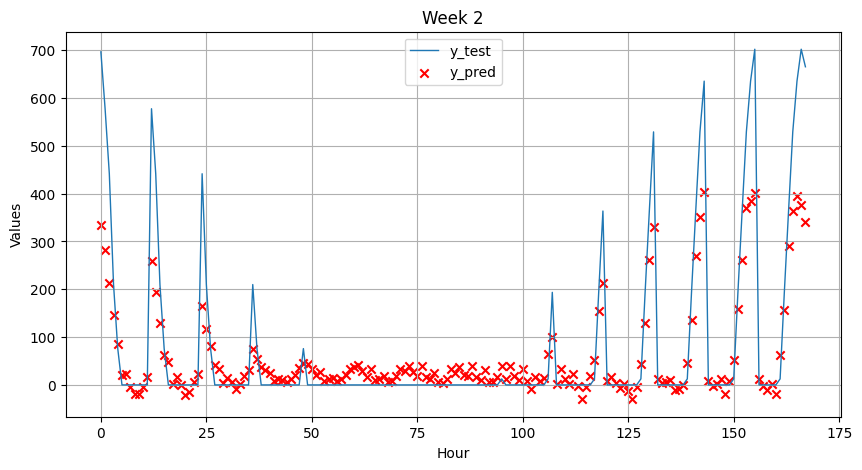

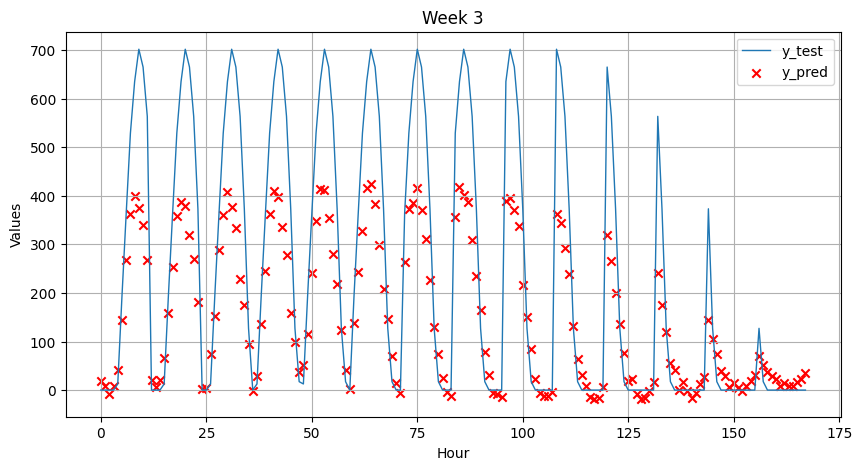

In [22]:
hours_per_week = 24 * 7

num_weeks = len(y_pred) // hours_per_week

for week in range(num_weeks):
    start_idx = week * hours_per_week
    end_idx = start_idx + hours_per_week
    plt.figure(figsize=(10, 5))  # Set ukuran figure
    plt.plot(y_test[start_idx:end_idx], label='y_test', linewidth=1)
    plt.scatter(range(hours_per_week), y_pred[start_idx:end_idx], color='red', marker='x', label='y_pred')
    plt.title(f'Week {week + 1}')
    plt.xlabel('Hour')
    plt.ylabel('Values')
    plt.legend()
    plt.grid(True)
    plt.show()